In [79]:
import yaml
import subprocess
import os

In [80]:
with open('dvc.yaml', 'r') as file:
    stages = yaml.safe_load(file)

executed_stages = {}

In [78]:
for stage_name, stage in stages['stages'].items():
    for dep in stage['deps']:
        if not os.path.exists(dep):
            print(f"Error: No such dependency as {dep}")
            exit(1)

    print(f'Stage running: {stage_name}')
    result = subprocess.run(stage['cmd'], shell=True)

    if result.returncode != 0:
        print(f"Error during completing stage: {stage_name}.")
        exit(1)

print("All completed")

Stage running: preprocessing
Stage running: eda
Stage running: pipeline
Stage running: linear_regression
Stage running: tree
Stage running: catboost
Stage running: neural_network
All completed


In [82]:
import networkx as nx
import matplotlib.pyplot as plt

In [90]:
with open('C:/Users/kseni/PycharmProjects/tpu-8e21-ai-basis/Fomina/dvc.yaml', 'r') as file:
    dvc_data = yaml.safe_load(file)

graph = nx.DiGraph()

for stage_name, stage_info in dvc_data['stages'].items():
    graph.add_node(stage_name)
    for dep in stage_info.get('deps', []):
        graph.add_edge(dep, stage_name)

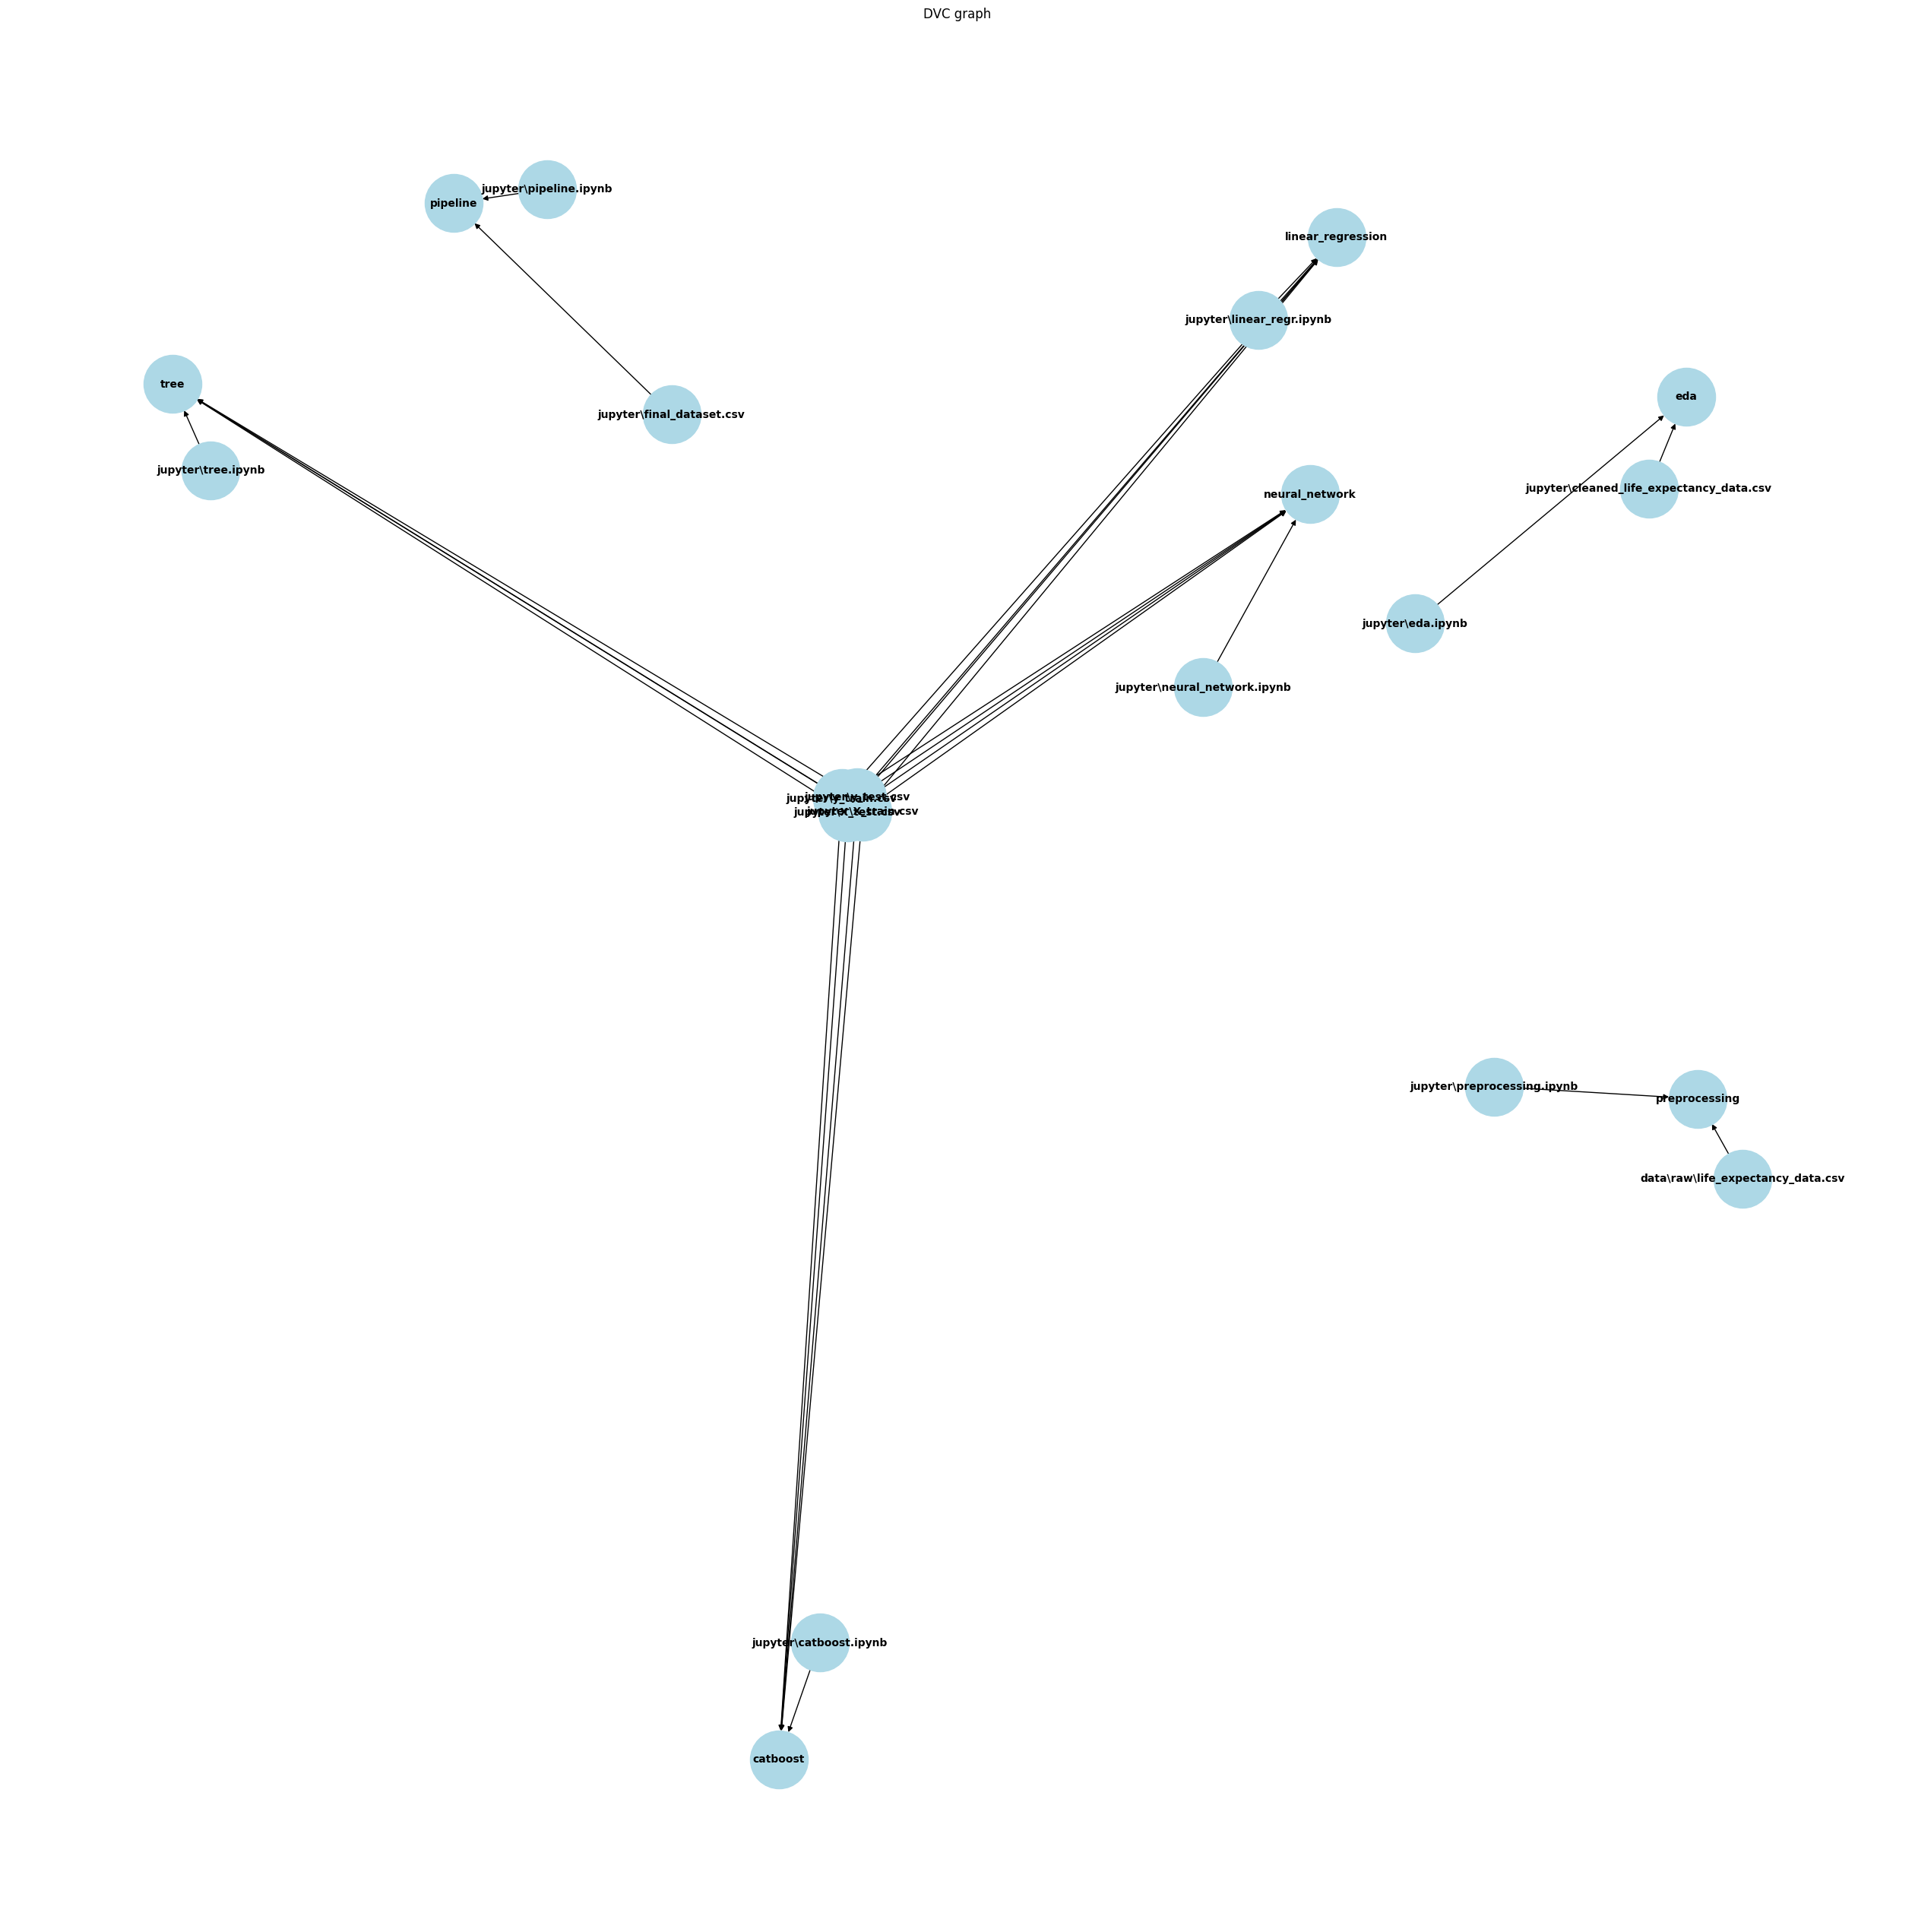

In [99]:
plt.figure(figsize=(25, 25))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)
plt.title("DVC graph")
plt.show()